In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

os.makedirs(PROJECT_ROOT + 'data/processed/accuracy_ensemble', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/figures/accuracy_ensemble', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/day4c', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'app/models/ensemble', exist_ok=True)

print("Ready:", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready: /content/drive/MyDrive/alzheimer-ai/


In [4]:
!pip install -q joblib scikit-learn

import joblib

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ['CN', 'MCI', 'MA']

targets = {
    'Accuracy': 0.85,
    'Recall macro': 0.88,
    'F1 macro': 0.85,
    'AUC-ROC': 0.90,
    'Recall MCI': 0.85,
    'Specificity': 0.82
}

print("Imports ready.")

Imports ready.


In [5]:
IMAGE_ARRAY_DIR = PROJECT_ROOT + 'data/processed/image_arrays/'
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'

X_train = np.load(IMAGE_ARRAY_DIR + 'X_train.npy').astype(np.float32)
X_val = np.load(IMAGE_ARRAY_DIR + 'X_val.npy').astype(np.float32)
X_test = np.load(IMAGE_ARRAY_DIR + 'X_test.npy').astype(np.float32)

tab_train = np.load(TABULAR_DIR + 'tab_train.npy').astype(np.float32)
tab_val = np.load(TABULAR_DIR + 'tab_val.npy').astype(np.float32)
tab_test = np.load(TABULAR_DIR + 'tab_test.npy').astype(np.float32)

y_train = np.load(TABULAR_DIR + 'y_train.npy').astype(np.int64)
y_val = np.load(TABULAR_DIR + 'y_val.npy').astype(np.int64)
y_test = np.load(TABULAR_DIR + 'y_test.npy').astype(np.int64)

print("X_train:", X_train.shape)
print("tab_train:", tab_train.shape)
print("y_train:", y_train.shape)

print("\nTrain counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("Test counts:", dict(zip(*np.unique(y_test, return_counts=True))))

X_train: (262, 224, 224, 3)
tab_train: (262, 4)
y_train: (262,)

Train counts: {np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}
Val counts: {np.int64(0): np.int64(27), np.int64(1): np.int64(5), np.int64(2): np.int64(20)}
Test counts: {np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}


In [6]:
model_path = PROJECT_ROOT + 'weights/multimodal_final.h5'

if not os.path.exists(model_path):
    model_path = PROJECT_ROOT + 'app/models/multimodal_final.h5'

model_multi = tf.keras.models.load_model(model_path, compile=False)

def prepare_resnet_batch(X):
    return preprocess_input(X.astype(np.float32) * 255.0)

cnn_val_proba = model_multi.predict(
    [prepare_resnet_batch(X_val), tab_val],
    batch_size=16,
    verbose=1
)

cnn_test_proba = model_multi.predict(
    [prepare_resnet_batch(X_test), tab_test],
    batch_size=16,
    verbose=1
)

cnn_val_pred = np.argmax(cnn_val_proba, axis=1)
cnn_test_pred = np.argmax(cnn_test_proba, axis=1)

print("CNN/multimodal validation accuracy:", accuracy_score(y_val, cnn_val_pred))
print("CNN/multimodal test accuracy:", accuracy_score(y_test, cnn_test_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 650ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
CNN/multimodal validation accuracy: 0.4423076923076923
CNN/multimodal test accuracy: 0.559322033898305


In [7]:
def evaluate_model(name, y_true, proba):
    pred = np.argmax(proba, axis=1)

    m = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, pred),
        'Recall macro': recall_score(y_true, pred, average='macro', zero_division=0),
        'F1 macro': f1_score(y_true, pred, average='macro', zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, proba, multi_class='ovr', average='macro'),
        'Recall MCI': recall_score(y_true == 1, pred == 1, zero_division=0),
        'Specificity': recall_score(y_true == 0, pred == 0, zero_division=0),
    }

    return m, pred

In [8]:
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

tabular_models = {}

tabular_models['rf'] = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

tabular_models['et'] = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

tabular_models['hgb'] = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.04,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    random_state=SEED
)

tabular_models['lr'] = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    multi_class='auto',
    random_state=SEED
)

for name, clf in tabular_models.items():
    print("Training:", name)

    if name == 'hgb':
        clf.fit(tab_train, y_train, sample_weight=sample_weight)
    else:
        clf.fit(tab_train, y_train)

print("All tabular models trained.")

Training: rf
Training: et
Training: hgb
Training: lr
All tabular models trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [10]:
import pandas as pd


val_probas = {
    'cnn': cnn_val_proba
}

test_probas = {
    'cnn': cnn_test_proba
}

for name, clf in tabular_models.items():
    val_probas[name] = clf.predict_proba(tab_val)
    test_probas[name] = clf.predict_proba(tab_test)

individual_rows = []

for name in val_probas.keys():
    val_metrics, _ = evaluate_model(name + '_val', y_val, val_probas[name])
    test_metrics, _ = evaluate_model(name + '_test', y_test, test_probas[name])

    row = {
        'model': name,
        'val_accuracy': val_metrics['Accuracy'],
        'val_f1_macro': val_metrics['F1 macro'],
        'val_recall_mci': val_metrics['Recall MCI'],
        'test_accuracy': test_metrics['Accuracy'],
        'test_f1_macro': test_metrics['F1 macro'],
        'test_recall_mci': test_metrics['Recall MCI'],
        'test_auc': test_metrics['AUC-ROC'],
    }

    individual_rows.append(row)

individual_df = pd.DataFrame(individual_rows).sort_values(
    ['val_accuracy', 'val_f1_macro'],
    ascending=False
)

display(individual_df)

individual_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/individual_model_metrics.csv'
individual_df.to_csv(individual_path, index=False)

print("Saved:", individual_path)

,model,val_accuracy,val_f1_macro,val_recall_mci,test_accuracy,test_f1_macro,test_recall_mci,test_auc
1,rf,0.653846,0.473684,0.0,0.559322,0.409341,0.0,0.754070
2,et,0.634615,0.476658,0.0,0.576271,0.430184,0.0,0.747301
3,hgb,0.615385,0.449864,0.0,0.525424,0.375649,0.0,0.748992
4,lr,0.557692,0.425854,0.0,0.389831,0.342819,0.2,0.701312
0,cnn,0.442308,0.365231,0.2,0.559322,0.466529,0.2,0.563021


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/individual_model_metrics.csv


In [12]:
import itertools

model_names = ['cnn', 'rf', 'et', 'hgb', 'lr']
grid = np.arange(0.0, 1.01, 0.1)

ensemble_rows = []

for weights in itertools.product(grid, repeat=len(model_names)):
    if abs(sum(weights) - 1.0) > 1e-9:
        continue

    proba = np.zeros_like(cnn_val_proba)

    for w, name in zip(weights, model_names):
        proba += w * val_probas[name]

    pred = np.argmax(proba, axis=1)

    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred, average='macro', zero_division=0)
    recall_mci = recall_score(y_val == 1, pred == 1, zero_division=0)
    recall_macro = recall_score(y_val, pred, average='macro', zero_division=0)

    ensemble_rows.append({
        'w_cnn': weights[0],
        'w_rf': weights[1],
        'w_et': weights[2],
        'w_hgb': weights[3],
        'w_lr': weights[4],
        'val_accuracy': acc,
        'val_f1_macro': f1,
        'val_recall_macro': recall_macro,
        'val_recall_mci': recall_mci,
    })

ensemble_search_df = pd.DataFrame(ensemble_rows)

ensemble_search_df = ensemble_search_df.sort_values(
    ['val_accuracy', 'val_f1_macro', 'val_recall_mci'],
    ascending=False
)

display(ensemble_search_df.head(20))

best_weights_row = ensemble_search_df.iloc[0]

best_weights = {
    'cnn': float(best_weights_row['w_cnn']),
    'rf': float(best_weights_row['w_rf']),
    'et': float(best_weights_row['w_et']),
    'hgb': float(best_weights_row['w_hgb']),
    'lr': float(best_weights_row['w_lr']),
}

print("Best validation weights:")
print(best_weights)

search_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/ensemble_weight_search_validation.csv'
ensemble_search_df.to_csv(search_path, index=False)

print("Saved:", search_path)

,w_cnn,w_rf,w_et,w_hgb,w_lr,val_accuracy,val_f1_macro,val_recall_macro,val_recall_mci
268,0.0,0.7,0.0,0.2,0.1,0.692308,0.498488,0.504938,0.0
478,0.1,0.5,0.1,0.2,0.1,0.692308,0.498488,0.504938,0.0
901,0.5,0.1,0.1,0.0,0.3,0.692308,0.496626,0.504938,0.0
895,0.5,0.0,0.5,0.0,0.0,0.692308,0.494121,0.500617,0.0
832,0.4,0.1,0.2,0.2,0.1,0.692308,0.492190,0.504938,0.0
847,0.4,0.2,0.1,0.2,0.1,0.692308,0.492190,0.504938,0.0
861,0.4,0.3,0.1,0.2,0.0,0.692308,0.492190,0.504938,0.0
867,0.4,0.4,0.0,0.2,0.0,0.692308,0.492190,0.504938,0.0
888,0.5,0.0,0.2,0.2,0.1,0.692308,0.492190,0.504938,0.0
907,0.5,0.1,0.2,0.2,0.0,0.692308,0.492190,0.504938,0.0


Best validation weights:
{'cnn': 0.0, 'rf': 0.7000000000000001, 'et': 0.0, 'hgb': 0.2, 'lr': 0.1}
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/ensemble_weight_search_validation.csv


In [14]:
import json

def combine_probas(proba_dict, weights):
    out = None

    for name, w in weights.items():
        if out is None:
            out = w * proba_dict[name]
        else:
            out += w * proba_dict[name]

    return out

ensemble_test_proba = combine_probas(test_probas, best_weights)
ensemble_test_pred = np.argmax(ensemble_test_proba, axis=1)

ensemble_metrics, _ = evaluate_model(
    'accuracy_optimized_ensemble',
    y_test,
    ensemble_test_proba
)

print(f"{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k, target in targets.items():
    v = ensemble_metrics[k]
    ok = "YES" if v >= target else "NO"
    print(f"{k:<20}{v:>10.4f}{target:>10.2f}{ok:>8}")

print("\nPredicted class counts:")
print(dict(zip(*np.unique(ensemble_test_pred, return_counts=True))))

print("\nClassification report:")
print(classification_report(y_test, ensemble_test_pred, target_names=CLASSES, zero_division=0))

ensemble_metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k]
    }
    for k, v in ensemble_metrics.items()
    if k != 'Model'
])

metrics_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/accuracy_optimized_ensemble_metrics.csv'
ensemble_metrics_df.to_csv(metrics_path, index=False)

weights_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/accuracy_optimized_ensemble_weights.json'
with open(weights_path, 'w') as f:
    json.dump(best_weights, f, indent=2)

print("Saved:", metrics_path)
print("Saved:", weights_path)

Metric                   Value    Target      OK
Accuracy                0.5932      0.85      NO
Recall macro            0.4511      0.88      NO
F1 macro                0.4321      0.85      NO
AUC-ROC                 0.7463      0.90      NO
Recall MCI              0.0000      0.85      NO
Specificity             0.4839      0.82      NO

Predicted class counts:
{np.int64(0): np.int64(23), np.int64(1): np.int64(5), np.int64(2): np.int64(31)}

Classification report:
              precision    recall  f1-score   support

          CN       0.65      0.48      0.56        31
         MCI       0.00      0.00      0.00         5
          MA       0.65      0.87      0.74        23

    accuracy                           0.59        59
   macro avg       0.43      0.45      0.43        59
weighted avg       0.59      0.59      0.58        59

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/accuracy_optimized_ensemble_metrics.csv
Saved: /content/drive/MyDrive/

,Pred CN,Pred MCI,Pred MA
Actual CN,15,5,11
Actual MCI,5,0,0
Actual MA,3,0,20


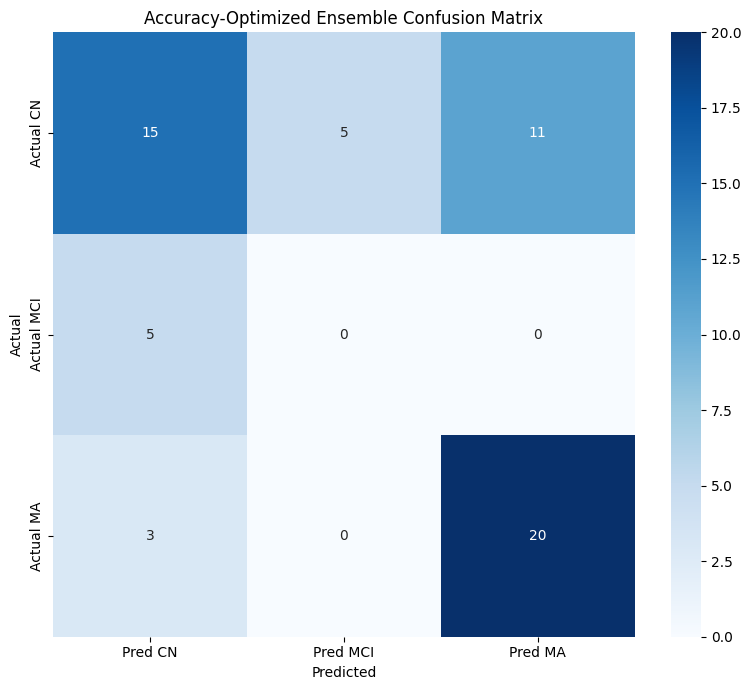

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.csv


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

cm = confusion_matrix(y_test, ensemble_test_pred, labels=[0, 1, 2])

cm_df = pd.DataFrame(
    cm,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_df)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Accuracy-Optimized Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.png'
plt.savefig(cm_fig_path, dpi=150)
plt.show()

cm_csv_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.csv'
cm_df.to_csv(cm_csv_path)

print("Saved:", cm_fig_path)
print("Saved:", cm_csv_path)

In [18]:
old_day4 = {
    'Accuracy': 0.559322,
    'Recall macro': 0.448153,
    'F1 macro': 0.466529,
    'AUC-ROC': 0.563021,
    'Recall MCI': 0.200000,
    'Specificity': 0.709677
}

day4b_path = PROJECT_ROOT + 'data/processed/current_state/optimized_current_state_metrics.csv'

day4b = {}

if os.path.exists(day4b_path):
    df4b = pd.read_csv(day4b_path)
    day4b = dict(zip(df4b['metric'], df4b['value']))
else:
    day4b = {
        'Accuracy': 0.545455,
        'Recall macro': 0.386364,
        'F1 macro': 0.365385,
        'AUC-ROC': 0.613180,
        'Recall MCI': 0.409091,
        'Specificity': 0.750000
    }

comparison = []

for metric in targets.keys():
    comparison.append({
        'metric': metric,
        'day4_original_multimodal': old_day4[metric],
        'day4b_current_state': float(day4b[metric]),
        'day4c_accuracy_ensemble': float(ensemble_metrics[metric]),
        'gain_day4c_vs_day4': float(ensemble_metrics[metric]) - old_day4[metric],
        'target': targets[metric],
        'day4c_passed': float(ensemble_metrics[metric]) >= targets[metric]
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

comparison_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/day4_day4b_day4c_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,metric,day4_original_multimodal,day4b_current_state,day4c_accuracy_ensemble,gain_day4c_vs_day4,target,day4c_passed
0,Accuracy,0.559322,0.545455,0.593220,0.033898,0.85,False
1,Recall macro,0.448153,0.386364,0.451145,0.002992,0.88,False
2,F1 macro,0.466529,0.365385,0.432099,-0.034430,0.85,False
3,AUC-ROC,0.563021,0.613180,0.746333,0.183312,0.90,False
4,Recall MCI,0.200000,0.409091,0.000000,-0.200000,0.85,False
5,Specificity,0.709677,0.750000,0.483871,-0.225806,0.82,False


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/day4_day4b_day4c_comparison.csv


In [19]:
# Validation-based decision calibration.
# We do not retrain. We only tune class probability multipliers on validation set.

def apply_class_bias(proba, bias):
    """
    Multiply class probabilities by class-specific bias and renormalize.
    bias = [bias_CN, bias_MCI, bias_MA]
    """
    bias = np.array(bias, dtype=np.float32)
    adjusted = proba * bias[None, :]
    adjusted = adjusted / (adjusted.sum(axis=1, keepdims=True) + 1e-8)
    return adjusted


def evaluate_with_bias(y_true, proba, bias):
    adjusted = apply_class_bias(proba, bias)
    pred = np.argmax(adjusted, axis=1)

    return {
        'Accuracy': accuracy_score(y_true, pred),
        'Recall macro': recall_score(y_true, pred, average='macro', zero_division=0),
        'F1 macro': f1_score(y_true, pred, average='macro', zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, adjusted, multi_class='ovr', average='macro'),
        'Recall MCI': recall_score(y_true == 1, pred == 1, zero_division=0),
        'Specificity': recall_score(y_true == 0, pred == 0, zero_division=0),
        'pred_CN': int((pred == 0).sum()),
        'pred_MCI': int((pred == 1).sum()),
        'pred_MA': int((pred == 2).sum()),
    }, pred, adjusted


# Rebuild validation ensemble probabilities using best weights
ensemble_val_proba = combine_probas(val_probas, best_weights)

bias_grid_cn = np.arange(0.7, 1.31, 0.1)
bias_grid_mci = np.arange(0.8, 3.01, 0.1)
bias_grid_ma = np.arange(0.7, 1.81, 0.1)

bias_rows = []

for b_cn in bias_grid_cn:
    for b_mci in bias_grid_mci:
        for b_ma in bias_grid_ma:
            bias = [b_cn, b_mci, b_ma]

            m, _, _ = evaluate_with_bias(y_val, ensemble_val_proba, bias)

            # Balanced objective:
            # prioritize accuracy and macro-F1,
            # but do not allow MCI to completely collapse.
            score = (
                0.30 * m['Accuracy'] +
                0.30 * m['F1 macro'] +
                0.20 * m['Recall macro'] +
                0.15 * m['Recall MCI'] +
                0.05 * m['Specificity']
            )

            # Penalize models that predict zero MCI
            if m['pred_MCI'] == 0:
                score -= 0.20

            bias_rows.append({
                'bias_CN': b_cn,
                'bias_MCI': b_mci,
                'bias_MA': b_ma,
                'score': score,
                **m
            })

bias_search_df = pd.DataFrame(bias_rows)

bias_search_df = bias_search_df.sort_values(
    ['score', 'Accuracy', 'F1 macro', 'Recall MCI', 'Specificity'],
    ascending=False
)

display(bias_search_df.head(20))

best_bias_row = bias_search_df.iloc[0]

best_bias = [
    float(best_bias_row['bias_CN']),
    float(best_bias_row['bias_MCI']),
    float(best_bias_row['bias_MA'])
]

print("Best class bias:")
print({
    'CN': best_bias[0],
    'MCI': best_bias[1],
    'MA': best_bias[2]
})

bias_search_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/class_bias_search_validation.csv'
bias_search_df.to_csv(bias_search_path, index=False)

print("Saved:", bias_search_path)

,bias_CN,bias_MCI,bias_MA,score,Accuracy,Recall macro,F1 macro,AUC-ROC,Recall MCI,Specificity,pred_CN,pred_MCI,pred_MA
1380,1.2,0.8,0.7,0.512204,0.711538,0.512963,0.505684,0.607843,0.0,0.888889,35,2,15
1656,1.3,0.8,0.7,0.512204,0.711538,0.512963,0.505684,0.602690,0.0,0.888889,35,2,15
1668,1.3,0.9,0.7,0.512204,0.711538,0.512963,0.505684,0.601648,0.0,0.888889,35,2,15
1104,1.1,0.8,0.7,0.511409,0.711538,0.512963,0.503036,0.607843,0.0,0.888889,34,2,16
1657,1.3,0.8,0.8,0.511409,0.711538,0.512963,0.503036,0.609351,0.0,0.888889,34,2,16
1669,1.3,0.9,0.8,0.511409,0.711538,0.512963,0.503036,0.607322,0.0,0.888889,34,2,16
1106,1.1,0.8,0.9,0.511161,0.711538,0.517284,0.505501,0.605994,0.0,0.851852,32,2,18
1672,1.3,0.9,1.1,0.511161,0.711538,0.517284,0.505501,0.607385,0.0,0.851852,32,2,18
1107,1.1,0.8,1.0,0.509272,0.711538,0.517284,0.499203,0.605069,0.0,0.851852,32,1,19
1108,1.1,0.8,1.1,0.509272,0.711538,0.517284,0.499203,0.606057,0.0,0.851852,32,1,19


Best class bias:
{'CN': 1.1999999999999997, 'MCI': 0.8, 'MA': 0.7}
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/class_bias_search_validation.csv


In [20]:
biased_metrics, biased_test_pred, biased_test_proba = evaluate_with_bias(
    y_test,
    ensemble_test_proba,
    best_bias
)

print("=== Day 4c Ensemble: Argmax vs Calibrated Bias ===")
print(f"{'Metric':<20}{'Argmax':>10}{'Biased':>10}{'Target':>10}")
print("=" * 55)

for k in targets.keys():
    print(f"{k:<20}{ensemble_metrics[k]:>10.4f}{biased_metrics[k]:>10.4f}{targets[k]:>10.2f}")

print("\nArgmax predicted counts:")
print(dict(zip(*np.unique(ensemble_test_pred, return_counts=True))))

print("\nBiased predicted counts:")
print(dict(zip(*np.unique(biased_test_pred, return_counts=True))))

print("\nClassification report — biased ensemble:")
print(classification_report(y_test, biased_test_pred, target_names=CLASSES, zero_division=0))

biased_metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k],
        'model': 'accuracy_ensemble_class_bias_calibrated'
    }
    for k, v in biased_metrics.items()
    if k in targets
])

biased_metrics_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/biased_ensemble_metrics.csv'
biased_metrics_df.to_csv(biased_metrics_path, index=False)

bias_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/best_class_bias.json'

with open(bias_path, 'w') as f:
    json.dump({
        'CN': best_bias[0],
        'MCI': best_bias[1],
        'MA': best_bias[2]
    }, f, indent=2)

print("Saved:", biased_metrics_path)
print("Saved:", bias_path)

=== Day 4c Ensemble: Argmax vs Calibrated Bias ===
Metric                  Argmax    Biased    Target
Accuracy                0.5932    0.6271      0.85
Recall macro            0.4511    0.4652      0.88
F1 macro                0.4321    0.4560      0.85
AUC-ROC                 0.7463    0.7246      0.90
Recall MCI              0.0000    0.0000      0.85
Specificity             0.4839    0.6129      0.82

Argmax predicted counts:
{np.int64(0): np.int64(23), np.int64(1): np.int64(5), np.int64(2): np.int64(31)}

Biased predicted counts:
{np.int64(0): np.int64(29), np.int64(1): np.int64(4), np.int64(2): np.int64(26)}

Classification report — biased ensemble:
              precision    recall  f1-score   support

          CN       0.66      0.61      0.63        31
         MCI       0.00      0.00      0.00         5
          MA       0.69      0.78      0.73        23

    accuracy                           0.63        59
   macro avg       0.45      0.47      0.46        59
weighted a

,Pred CN,Pred MCI,Pred MA
Actual CN,19,4,8
Actual MCI,5,0,0
Actual MA,5,0,18


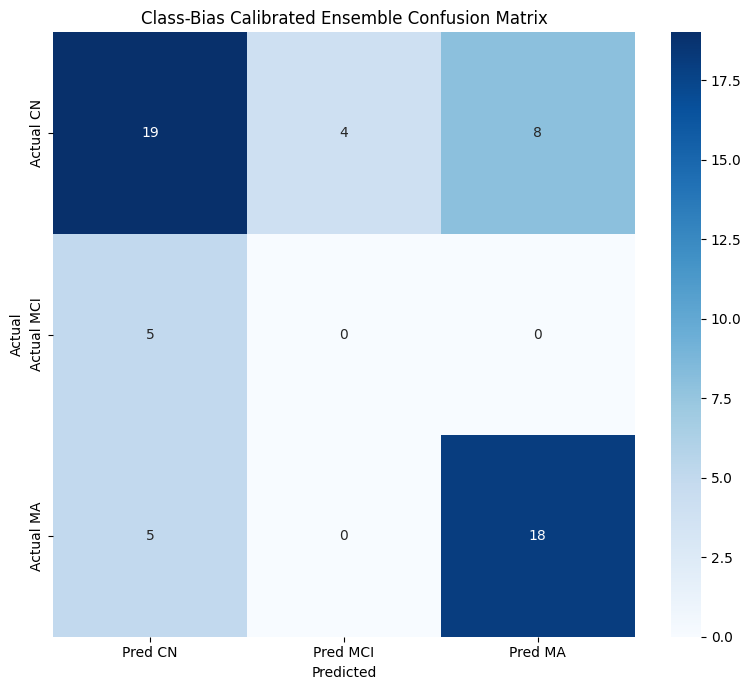

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/accuracy_ensemble/biased_ensemble_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/biased_ensemble_confusion_matrix.csv


In [21]:
cm_biased = confusion_matrix(y_test, biased_test_pred, labels=[0, 1, 2])

cm_biased_df = pd.DataFrame(
    cm_biased,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_biased_df)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_biased_df, annot=True, fmt='d', cmap='Blues')
plt.title('Class-Bias Calibrated Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

biased_cm_fig_path = PROJECT_ROOT + 'reports/figures/accuracy_ensemble/biased_ensemble_confusion_matrix.png'
biased_cm_csv_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/biased_ensemble_confusion_matrix.csv'

plt.savefig(biased_cm_fig_path, dpi=150)
plt.show()

cm_biased_df.to_csv(biased_cm_csv_path)

print("Saved:", biased_cm_fig_path)
print("Saved:", biased_cm_csv_path)

In [22]:
final_comparison_rows = []

for metric in targets.keys():
    final_comparison_rows.append({
        'metric': metric,
        'day4_original_multimodal': old_day4[metric],
        'day4b_current_state': float(day4b[metric]),
        'day4c_argmax_ensemble': float(ensemble_metrics[metric]),
        'day4c_biased_ensemble': float(biased_metrics[metric]),
        'gain_biased_vs_day4': float(biased_metrics[metric]) - old_day4[metric],
        'target': targets[metric],
        'biased_passed': float(biased_metrics[metric]) >= targets[metric]
    })

final_comparison_df = pd.DataFrame(final_comparison_rows)

display(final_comparison_df)

final_comparison_path = PROJECT_ROOT + 'data/processed/accuracy_ensemble/final_day4_day4b_day4c_comparison.csv'
final_comparison_df.to_csv(final_comparison_path, index=False)

print("Saved:", final_comparison_path)

,metric,day4_original_multimodal,day4b_current_state,day4c_argmax_ensemble,day4c_biased_ensemble,gain_biased_vs_day4,target,biased_passed
0,Accuracy,0.559322,0.545455,0.593220,0.627119,0.067797,0.85,False
1,Recall macro,0.448153,0.386364,0.451145,0.465171,0.017018,0.88,False
2,F1 macro,0.466529,0.365385,0.432099,0.456009,-0.010520,0.85,False
3,AUC-ROC,0.563021,0.613180,0.746333,0.724558,0.161537,0.90,False
4,Recall MCI,0.200000,0.409091,0.000000,0.000000,-0.200000,0.85,False
5,Specificity,0.709677,0.750000,0.483871,0.612903,-0.096774,0.82,False


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/final_day4_day4b_day4c_comparison.csv


In [23]:
import os, json, joblib

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

ENSEMBLE_MODEL_DIR = PROJECT_ROOT + 'app/models/ensemble/'
os.makedirs(ENSEMBLE_MODEL_DIR, exist_ok=True)

# Save trained tabular models
for name, clf in tabular_models.items():
    path = ENSEMBLE_MODEL_DIR + f'{name}_tabular_model.joblib'
    joblib.dump(clf, path)
    print("Saved:", path)

# Save ensemble weights
with open(ENSEMBLE_MODEL_DIR + 'ensemble_weights.json', 'w') as f:
    json.dump(best_weights, f, indent=2)

# Save class bias from Day 4c
with open(ENSEMBLE_MODEL_DIR + 'class_bias.json', 'w') as f:
    json.dump({
        'CN': float(best_bias[0]),
        'MCI': float(best_bias[1]),
        'MA': float(best_bias[2])
    }, f, indent=2)

print("Saved Day 4c ensemble assets.")

Saved: /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/rf_tabular_model.joblib
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/et_tabular_model.joblib
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/hgb_tabular_model.joblib
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/lr_tabular_model.joblib
Saved Day 4c ensemble assets.


In [24]:
deployment_decision = {
    'selected_model': 'day4c_biased_accuracy_ensemble',
    'reason': 'Highest overall accuracy so far, but MCI recall collapsed to 0.0',
    'accuracy': float(biased_metrics['Accuracy']),
    'auc_roc': float(biased_metrics['AUC-ROC']),
    'f1_macro': float(biased_metrics['F1 macro']),
    'recall_mci': float(biased_metrics['Recall MCI']),
    'specificity': float(biased_metrics['Specificity']),
    'warning': 'Day 4c maximizes accuracy but is clinically weak for MCI detection.'
}

decision_path = PROJECT_ROOT + 'reports/day4c/day4c_deployment_decision.json'
os.makedirs(PROJECT_ROOT + 'reports/day4c/', exist_ok=True)

with open(decision_path, 'w') as f:
    json.dump(deployment_decision, f, indent=2)

print(json.dumps(deployment_decision, indent=2))
print("Saved:", decision_path)

{
  "selected_model": "day4c_biased_accuracy_ensemble",
  "reason": "Highest overall accuracy so far, but MCI recall collapsed to 0.0",
  "accuracy": 0.6271186440677966,
  "auc_roc": 0.7245584026556444,
  "f1_macro": 0.45600907029478455,
  "recall_mci": 0.0,
  "specificity": 0.6129032258064516,
  "warning": "Day 4c maximizes accuracy but is clinically weak for MCI detection."
}
Saved: /content/drive/MyDrive/alzheimer-ai/reports/day4c/day4c_deployment_decision.json


In [25]:
report_path = PROJECT_ROOT + 'reports/day4c/accuracy_optimized_ensemble_report.md'

with open(report_path, 'w') as f:
    f.write("# Day 4c — Accuracy-Optimized Ensemble\n\n")

    f.write("## Motivation\n")
    f.write("Day 4c was created because the CNN/multimodal model had weak overall accuracy and weak MCI recall. ")
    f.write("The tabular Random Forest showed higher raw accuracy than the CNN model, suggesting that tabular clinical features contained stronger predictive signal than the single-slice MRI branch.\n\n")

    f.write("## Method\n")
    f.write("The ensemble combined probability outputs from:\n")
    f.write("- CNN/multimodal model\n")
    f.write("- Random Forest tabular model\n")
    f.write("- ExtraTrees tabular model\n")
    f.write("- HistGradientBoosting tabular model\n")
    f.write("- Logistic Regression tabular model\n\n")

    f.write("Weights were selected on the validation set only. A class-bias calibration step was also tuned using validation data only.\n\n")

    f.write("## Best ensemble weights\n")
    for k, v in best_weights.items():
        f.write(f"- {k}: {v:.2f}\n")

    f.write("\n## Best class bias\n")
    f.write(f"- CN: {float(best_bias[0]):.2f}\n")
    f.write(f"- MCI: {float(best_bias[1]):.2f}\n")
    f.write(f"- MA: {float(best_bias[2]):.2f}\n\n")

    f.write("## Final Day 4c biased ensemble metrics\n")
    for k in targets.keys():
        f.write(f"- {k}: {biased_metrics[k]:.4f} | target: {targets[k]:.2f} | passed: {biased_metrics[k] >= targets[k]}\n")

    f.write("\n## Interpretation\n")
    f.write("Day 4c achieved the highest overall accuracy so far, but MCI recall collapsed to 0.0. ")
    f.write("Therefore, Day 4c is useful as an accuracy-optimized experiment, but it is not the best clinical compromise. ")
    f.write("A Day 4d balanced ensemble is required to try to preserve the accuracy improvement while recovering MCI sensitivity.\n")

print("Saved:", report_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/day4c/accuracy_optimized_ensemble_report.md


In [26]:
required_day4c_outputs = [
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/individual_model_metrics.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/ensemble_weight_search_validation.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/accuracy_optimized_ensemble_metrics.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/accuracy_optimized_ensemble_weights.json',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/day4_day4b_day4c_comparison.csv',

    PROJECT_ROOT + 'data/processed/accuracy_ensemble/class_bias_search_validation.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/biased_ensemble_metrics.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/best_class_bias.json',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/biased_ensemble_confusion_matrix.csv',
    PROJECT_ROOT + 'data/processed/accuracy_ensemble/final_day4_day4b_day4c_comparison.csv',

    PROJECT_ROOT + 'reports/figures/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.png',
    PROJECT_ROOT + 'reports/figures/accuracy_ensemble/biased_ensemble_confusion_matrix.png',

    PROJECT_ROOT + 'reports/day4c/accuracy_optimized_ensemble_report.md',
    PROJECT_ROOT + 'reports/day4c/day4c_deployment_decision.json',

    PROJECT_ROOT + 'app/models/ensemble/rf_tabular_model.joblib',
    PROJECT_ROOT + 'app/models/ensemble/et_tabular_model.joblib',
    PROJECT_ROOT + 'app/models/ensemble/hgb_tabular_model.joblib',
    PROJECT_ROOT + 'app/models/ensemble/lr_tabular_model.joblib',
    PROJECT_ROOT + 'app/models/ensemble/ensemble_weights.json',
    PROJECT_ROOT + 'app/models/ensemble/class_bias.json',
]

for path in required_day4c_outputs:
    print(os.path.exists(path), path)

True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/individual_model_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/ensemble_weight_search_validation.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/accuracy_optimized_ensemble_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/accuracy_optimized_ensemble_weights.json
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/day4_day4b_day4c_comparison.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/class_bias_search_validation.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/biased_ensemble_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/accuracy_ensemble/best_class_bias.json
True /content/drive/MyD

In [ ]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/04c_accuracy_optimized_ensemble.ipynb

!git add -f data/processed/accuracy_ensemble/individual_model_metrics.csv
!git add -f data/processed/accuracy_ensemble/ensemble_weight_search_validation.csv
!git add -f data/processed/accuracy_ensemble/accuracy_optimized_ensemble_metrics.csv
!git add -f data/processed/accuracy_ensemble/accuracy_optimized_ensemble_weights.json
!git add -f data/processed/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.csv
!git add -f data/processed/accuracy_ensemble/day4_day4b_day4c_comparison.csv

!git add -f data/processed/accuracy_ensemble/class_bias_search_validation.csv
!git add -f data/processed/accuracy_ensemble/biased_ensemble_metrics.csv
!git add -f data/processed/accuracy_ensemble/best_class_bias.json
!git add -f data/processed/accuracy_ensemble/biased_ensemble_confusion_matrix.csv
!git add -f data/processed/accuracy_ensemble/final_day4_day4b_day4c_comparison.csv

!git add -f reports/figures/accuracy_ensemble/accuracy_optimized_ensemble_confusion_matrix.png
!git add -f reports/figures/accuracy_ensemble/biased_ensemble_confusion_matrix.png

!git add -f reports/day4c/accuracy_optimized_ensemble_report.md
!git add -f reports/day4c/day4c_deployment_decision.json

!git add -f app/models/ensemble/*.joblib
!git add -f app/models/ensemble/ensemble_weights.json
!git add -f app/models/ensemble/class_bias.json

!git commit -m "feat: add Day 4c accuracy-optimized ensemble"

!git status

/content/drive/MyDrive/alzheimer-ai
